In [18]:
import os

from opensoundscape.spectrogram import Spectrogram
from opensoundscape.audio import Audio
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd

# %matplotlib inline
# %config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = [12,5]

In [5]:
from tdl_annotation import *

## Annotation

4 of 21
Clip: ('/Users/lviotti/Library/CloudStorage/Dropbox/Work/Kitzes/datasets/kipu2025/2MM01186/Data/2MM01186_20250126_080003.wav', 340, 345)


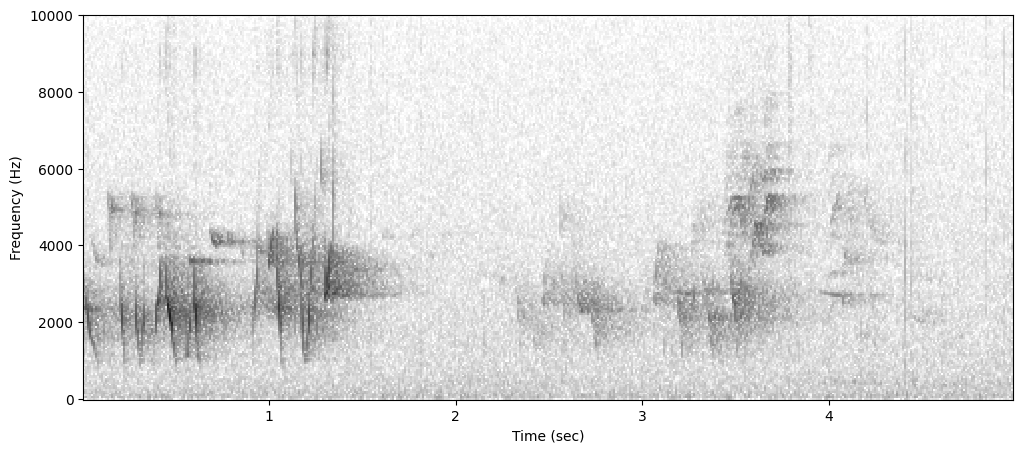

None

In [ ]:
annotate(
    scores_file = '/Users/lviotti/Library/CloudStorage/Dropbox/Work/Kitzes/projects/tdl-notebook/example/perch-predictions-kipu2025-local.csv',
    valid_annotations = [0, 1,'u','w'],
    index_cols = ['file_local', 'start_time', 'end_time'])

# Draft

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bioacoustics_model_zoo as bmz
from opensoundscape.audio import Audio
from opensoundscape.spectrogram import Spectrogram



In [2]:
model4 = bmz.SeparationModel(
  checkpoint='bird_mixit_model_checkpoints/output_sources4/model.ckpt-3223090',
)

model8 = bmz.SeparationModel(
  checkpoint='bird_mixit_model_checkpoints/output_sources8/model.ckpt-2178900',
)

INFO:tensorflow:Importing meta graph: bird_mixit_model_checkpoints/output_sources4/inference.meta
Restoring model from checkpoint:  bird_mixit_model_checkpoints/output_sources4/model.ckpt-3223090
INFO:tensorflow:Restoring parameters from bird_mixit_model_checkpoints/output_sources4/model.ckpt-3223090


I0000 00:00:1762368453.412272 5941007 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


INFO:tensorflow:Importing meta graph: bird_mixit_model_checkpoints/output_sources8/inference.meta
Restoring model from checkpoint:  bird_mixit_model_checkpoints/output_sources8/model.ckpt-2178900
INFO:tensorflow:Restoring parameters from bird_mixit_model_checkpoints/output_sources8/model.ckpt-2178900


In [ ]:
df = pd.read_csv('/Users/lviotti/Library/CloudStorage/Dropbox/Work/Kitzes/projects/tdl-notebook/example/perch-predictions-kipu2025-local.csv')
# df.file.iloc[0]

,file,file_local,start_time,end_time,omao,apapan,hawama,iiwi,akiapo,hawcre,akepa1,elepai,notes,date,recorder_id
0,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,315,320,12.571556,-12.264694,-11.746714,-8.279476,-12.594369,-7.123873,-9.500269,-12.528926,NaN,20250126,2MM01186
1,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,510,515,11.757702,-14.409378,-8.645014,-8.546747,-10.313908,-7.364929,-5.872106,-10.514591,NaN,20250126,2MM01186
2,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,955,960,11.694942,-9.209687,-8.555916,-5.360497,-7.986407,-2.736204,-1.170177,-10.965650,NaN,20250126,2MM01186
3,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,365,370,11.690182,-3.828780,-7.413135,-5.028522,-5.548864,-2.098103,-2.047067,-10.968410,NaN,20250126,2MM01186
4,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,340,345,11.117414,-12.785715,-8.454566,-9.305575,-12.749238,-4.254610,-5.418110,-11.747141,NaN,20250126,2MM01186
5,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,3050,3055,10.907751,-14.507205,-13.726054,-7.046395,-11.788392,-6.367053,-8.737360,-11.972278,NaN,20250126,2MM01186
6,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,1015,1020,10.800676,-9.227094,-9.157494,-9.548472,-11.714972,-5.109231,-3.770240,-10.513201,NaN,20250126,2MM01186
7,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,1515,1520,10.053530,-9.428876,-7.435085,-5.215104,-9.945288,-5.198160,-4.082984,-10.305099,NaN,20250126,2MM01186
8,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,245,250,10.005850,-11.240836,-11.326253,-10.049393,-12.598503,-8.945847,-7.489533,-11.212294,NaN,20250126,2MM01186
9,/media/kiwi/datasets/unfinalized/kipu2025/2MM0...,/Users/lviotti/Library/CloudStorage/Dropbox/Wo...,1055,1060,7.513293,-10.995268,-6.696457,-8.071600,-8.192217,-7.591868,-7.051997,-4.640911,NaN,20250125,2MM00813


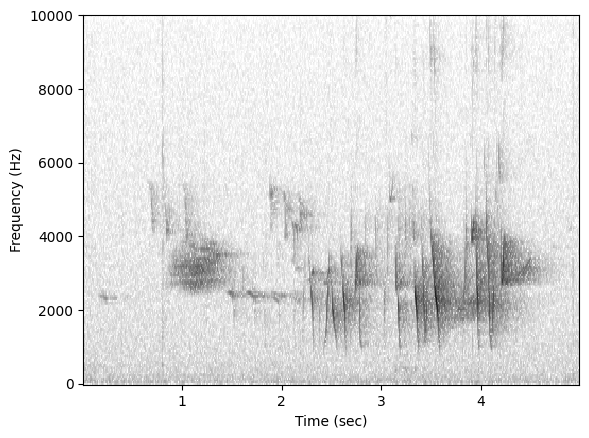

None

In [6]:
plot_clip(df.file_local.iloc[0], df.start_time.iloc[0], df.end_time.iloc[0])

In [8]:
def plot_clip_mixit(audio_path,
                    st=None,
                    end=None,
                    bandpass=[1, 10000],
                    mark_at_s=None,
                    buffer=None,
                    model=None,
                    max_sources=8,
                    play_audio=True,
                    window_samples=200,
                    cmap="Greys",
                    vmin=-100,
                    vmax=-20):
    """
    Like plot_clip(), but when a separation `model` is provided it also plots separated sources'
    spectrograms (adaptive grid, commonly 4 or 8) and plays the buffered/original audio.

    Args:
        audio_path (str): Audio file path (or whatever `plot_clip` expects as first arg).
        st (float): clip start (s).
        end (float): clip end (s).
        bandpass (list): [low_hz, high_hz] applied to audio/spectrogram.
        mark_at_s (list): seconds at which to draw vertical markers (relative to plotted audio).
        buffer (float): seconds to expand clip on each side (applied before separation/plotting).
        model (optional): object with `separate_audio(audio)` or `separate(audio)` returning an iterable
                          of sources (preferably opensoundscape.Audio objects).
        max_sources (int): maximum number of separated sources to plot (truncate if model returns more).
        play_audio (bool): whether to play/display the (buffered) combined audio at the end.
        window_samples (int): passed to Spectrogram.from_audio when computing spectrograms.
        cmap, vmin, vmax: visualization parameters for pcolormesh.
    """
    # --- load / apply buffer (same logic as plot_clip) ---
    if buffer and st is not None and end is not None:
        st_buffered = max(0, st - buffer)
        end_buffered = end + buffer
        dur = end_buffered - st_buffered
        audio = Audio.from_file(audio_path, offset=st_buffered, duration=dur).bandpass(bandpass[0], bandpass[1], order=10)
        # adjust mark positions to buffered-relative coordinates
        if mark_at_s is None:
            original_st_relative = st - st_buffered
            original_end_relative = end - st_buffered
            mark_at_s = [original_st_relative, original_end_relative]
        else:
            mark_at_s = [m - st_buffered for m in mark_at_s]
    else:
        # original behavior
        dur = end - st
        audio = Audio.from_file(audio_path, offset=st, duration=dur).bandpass(bandpass[0], bandpass[1], order=10)

    # If no model provided, behave exactly like plot_clip
    if model is None:
        ipd.display(Spectrogram.from_audio(audio).bandpass(bandpass[0], bandpass[1]).plot())
        if play_audio:
            ipd.display(ipd.Audio(audio.samples, rate=audio.sample_rate, autoplay=True))
        return

    # --- attempt to call model separation API (be defensive) ---
    try:
        separated = model.separate_audio(audio)
    except Exception:
        try:
            separated = model.separate(audio)
        except Exception as e:
            raise RuntimeError("Model separation failed: ensure model has `separate_audio` or `separate` method.") from e

    # --- normalize separated outputs into a list of opensoundscape.Audio objects ---
    clip_separated = []
    for src in separated:
        if isinstance(src, Audio):
            clip_separated.append(src)
        elif isinstance(src, (tuple, list)) and len(src) >= 2 and isinstance(src[0], (np.ndarray, list)):
            # treat as (samples, sample_rate) or similar
            samples = np.asarray(src[0])
            sr = int(src[1])
            clip_separated.append(Audio(samples=samples, sample_rate=sr))
        elif isinstance(src, np.ndarray):
            # samples only
            clip_separated.append(Audio(samples=src, sample_rate=audio.sample_rate))
        else:
            # try duck-typing: objects with .samples and .sample_rate
            samples = getattr(src, "samples", None)
            sr = getattr(src, "sample_rate", None)
            if samples is not None and sr is not None:
                clip_separated.append(Audio(samples=np.asarray(samples), sample_rate=int(sr)))
            else:
                raise TypeError(f"Unknown separated source type: {type(src)}. Expected Audio, (samples,sr), or ndarray.")

    # Truncate if model returned more than allowed
    total_sources = len(clip_separated)
    n_sources = min(total_sources, max_sources)
    if total_sources > n_sources:
        print(f"Model returned {total_sources} sources; plotting first {n_sources}. Increase max_sources to show more.")

    if n_sources == 0:
        print("Model returned no separated sources to plot.")
        return

    # --- compute grid layout ---
    n_cols = int(np.ceil(np.sqrt(n_sources)))
    n_rows = int(np.ceil(n_sources / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    # normalize axes to flat list for consistent indexing
    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    # --- plot each separated source spectrogram ---
    for i in range(n_sources):
        src_audio = clip_separated[i]
        spec = Spectrogram.from_audio(src_audio, window_samples=window_samples).bandpass(bandpass[0], bandpass[1])
        y = spec.frequencies
        t = spec.times
        S = spec.spectrogram
        ax = axes_flat[i]
        im = ax.pcolormesh(t, y, S, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Source {i+1}")
        ax.set_xlabel("Time (sec)")
        ax.set_ylabel("Frequency (Hz)")
        # add vertical markers relative to this plotted audio
        if mark_at_s is not None:
            for s in mark_at_s:
                ax.axvline(x=s, color='b')

    # hide any unused axes
    for j in range(n_sources, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # play/display combined buffered audio (same behavior as plot_clip)
    if play_audio:
        ipd.display(ipd.Audio(audio.samples, rate=audio.sample_rate, autoplay=True))

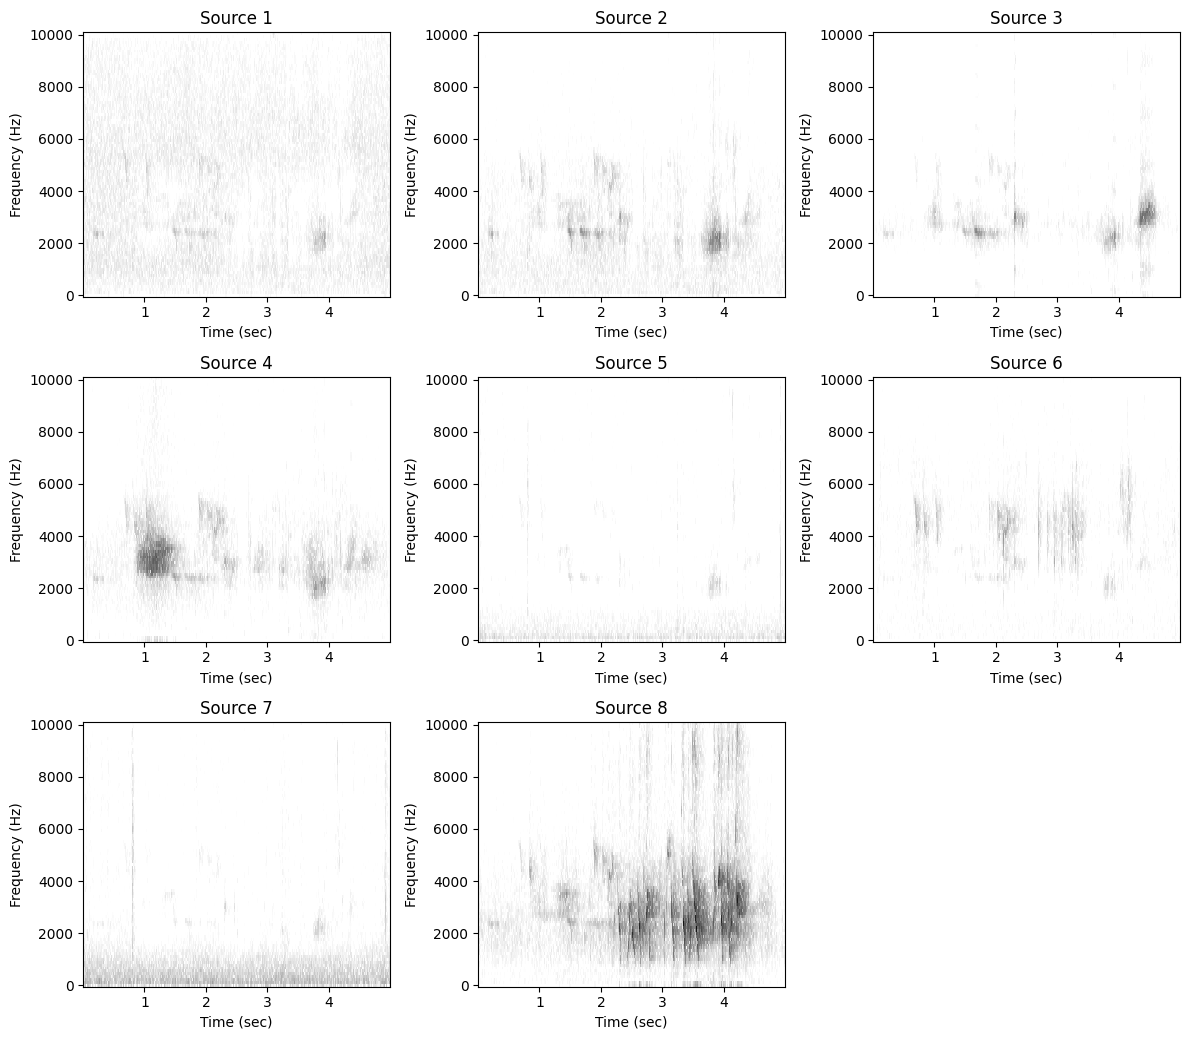

In [19]:
plot_clip_mixit(df.file_local.iloc[0], df.start_time.iloc[0], df.end_time.iloc[0], model = model8)